In [554]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [555]:
df = pd.read_csv("/Users/srisuphachawla/Documents/DataScience_Projects/SupplyChain/supply_chain_data.csv")
df

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,haircare,SKU95,77.903927,65,672,7386.363944,Unknown,15,14,26,...,Mumbai,18,450,26,58.890686,Pending,1.210882,Air,Route A,778.864241
96,cosmetics,SKU96,24.423131,29,324,7698.424766,Non-binary,67,2,32,...,Mumbai,28,648,28,17.803756,Pending,3.872048,Road,Route A,188.742141
97,haircare,SKU97,3.526111,56,62,4370.916580,Male,46,19,4,...,Mumbai,10,535,13,65.765156,Fail,3.376238,Road,Route A,540.132423
98,skincare,SKU98,19.754605,43,913,8525.952560,Female,53,1,27,...,Chennai,28,581,9,5.604691,Pending,2.908122,Rail,Route A,882.198864


In [556]:
# SKU is the identifier, make it into index
df.set_index("SKU", inplace = True)

### Dataset Overview

In [557]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, SKU0 to SKU99
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    object 
 1   Price                    100 non-null    float64
 2   Availability             100 non-null    int64  
 3   Number of products sold  100 non-null    int64  
 4   Revenue generated        100 non-null    float64
 5   Customer demographics    100 non-null    object 
 6   Stock levels             100 non-null    int64  
 7   Lead times               100 non-null    int64  
 8   Order quantities         100 non-null    int64  
 9   Shipping times           100 non-null    int64  
 10  Shipping carriers        100 non-null    object 
 11  Shipping costs           100 non-null    float64
 12  Supplier name            100 non-null    object 
 13  Location                 100 non-null    object 
 14  Lead time                1

In [558]:
df.describe()

,Price,Availability,Number of products sold,Revenue generated,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Defect rates,Costs
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000
mean,49.462461,48.400000,460.990000,5776.048187,47.770000,15.960000,49.220000,5.750000,5.548149,17.080000,567.840000,14.77000,47.266693,2.277158,529.245782
std,31.168193,30.743317,303.780074,2732.841744,31.369372,8.785801,26.784429,2.724283,2.651376,8.846251,263.046861,8.91243,28.982841,1.461366,258.301696
min,1.699976,1.000000,8.000000,1061.618523,0.000000,1.000000,1.000000,1.000000,1.013487,1.000000,104.000000,1.00000,1.085069,0.018608,103.916248
25%,19.597823,22.750000,184.250000,2812.847151,16.750000,8.000000,26.000000,3.750000,3.540248,10.000000,352.000000,7.00000,22.983299,1.009650,318.778455
50%,51.239831,43.500000,392.500000,6006.352023,47.500000,17.000000,52.000000,6.000000,5.320534,18.000000,568.500000,14.00000,45.905622,2.141863,520.430444
75%,77.198228,75.000000,704.250000,8253.976921,73.000000,24.000000,71.250000,8.000000,7.601695,25.000000,797.000000,23.00000,68.621026,3.563995,763.078231
max,99.171329,100.000000,996.000000,9866.465458,100.000000,30.000000,96.000000,10.000000,9.929816,30.000000,985.000000,30.00000,99.466109,4.939255,997.413450


In [559]:
df.duplicated().sum()

np.int64(0)

### Summary Statistics

In [560]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Price,100.0,49.462461,31.168193,1.699976,19.597823,51.239831,77.198228,99.171329
Availability,100.0,48.400000,30.743317,1.000000,22.750000,43.500000,75.000000,100.000000
Number of products sold,100.0,460.990000,303.780074,8.000000,184.250000,392.500000,704.250000,996.000000
Revenue generated,100.0,5776.048187,2732.841744,1061.618523,2812.847151,6006.352023,8253.976921,9866.465458
Stock levels,100.0,47.770000,31.369372,0.000000,16.750000,47.500000,73.000000,100.000000
Lead times,100.0,15.960000,8.785801,1.000000,8.000000,17.000000,24.000000,30.000000
Order quantities,100.0,49.220000,26.784429,1.000000,26.000000,52.000000,71.250000,96.000000
Shipping times,100.0,5.750000,2.724283,1.000000,3.750000,6.000000,8.000000,10.000000
Shipping costs,100.0,5.548149,2.651376,1.013487,3.540248,5.320534,7.601695,9.929816
Lead time,100.0,17.080000,8.846251,1.000000,10.000000,18.000000,25.000000,30.000000


In [561]:
df.describe(include="object").T

,count,unique,top,freq
Product type,100,3,skincare,40
Customer demographics,100,4,Unknown,31
Shipping carriers,100,3,Carrier B,43
Supplier name,100,5,Supplier 1,27
Location,100,5,Kolkata,25
Inspection results,100,3,Pending,41
Transportation modes,100,4,Road,29
Routes,100,3,Route A,43


### Numerical EDA

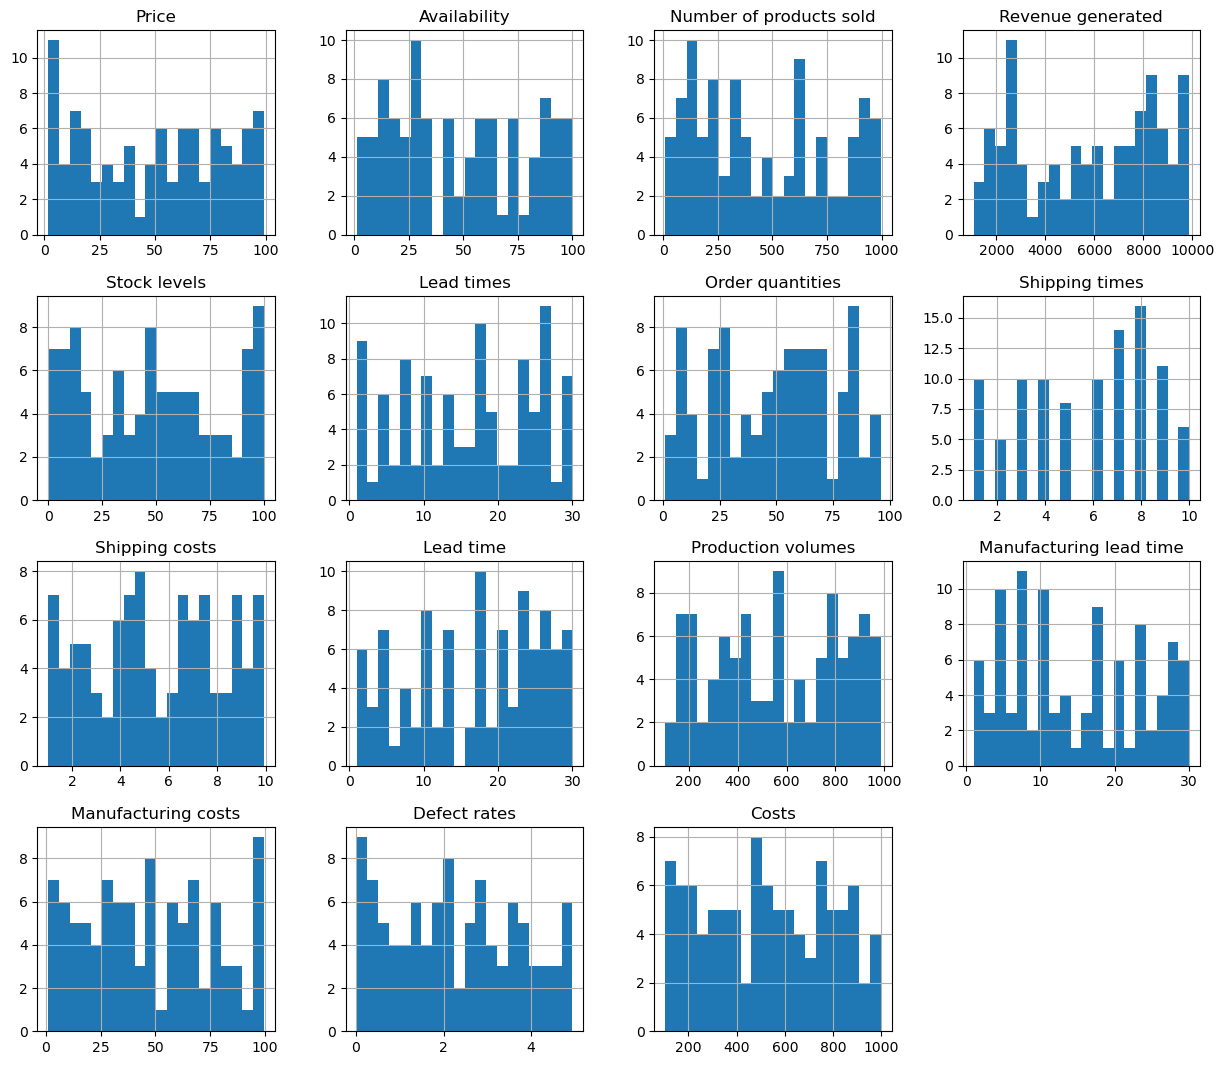

In [562]:
df.hist(figsize=(15,13), bins =20)
plt.show()

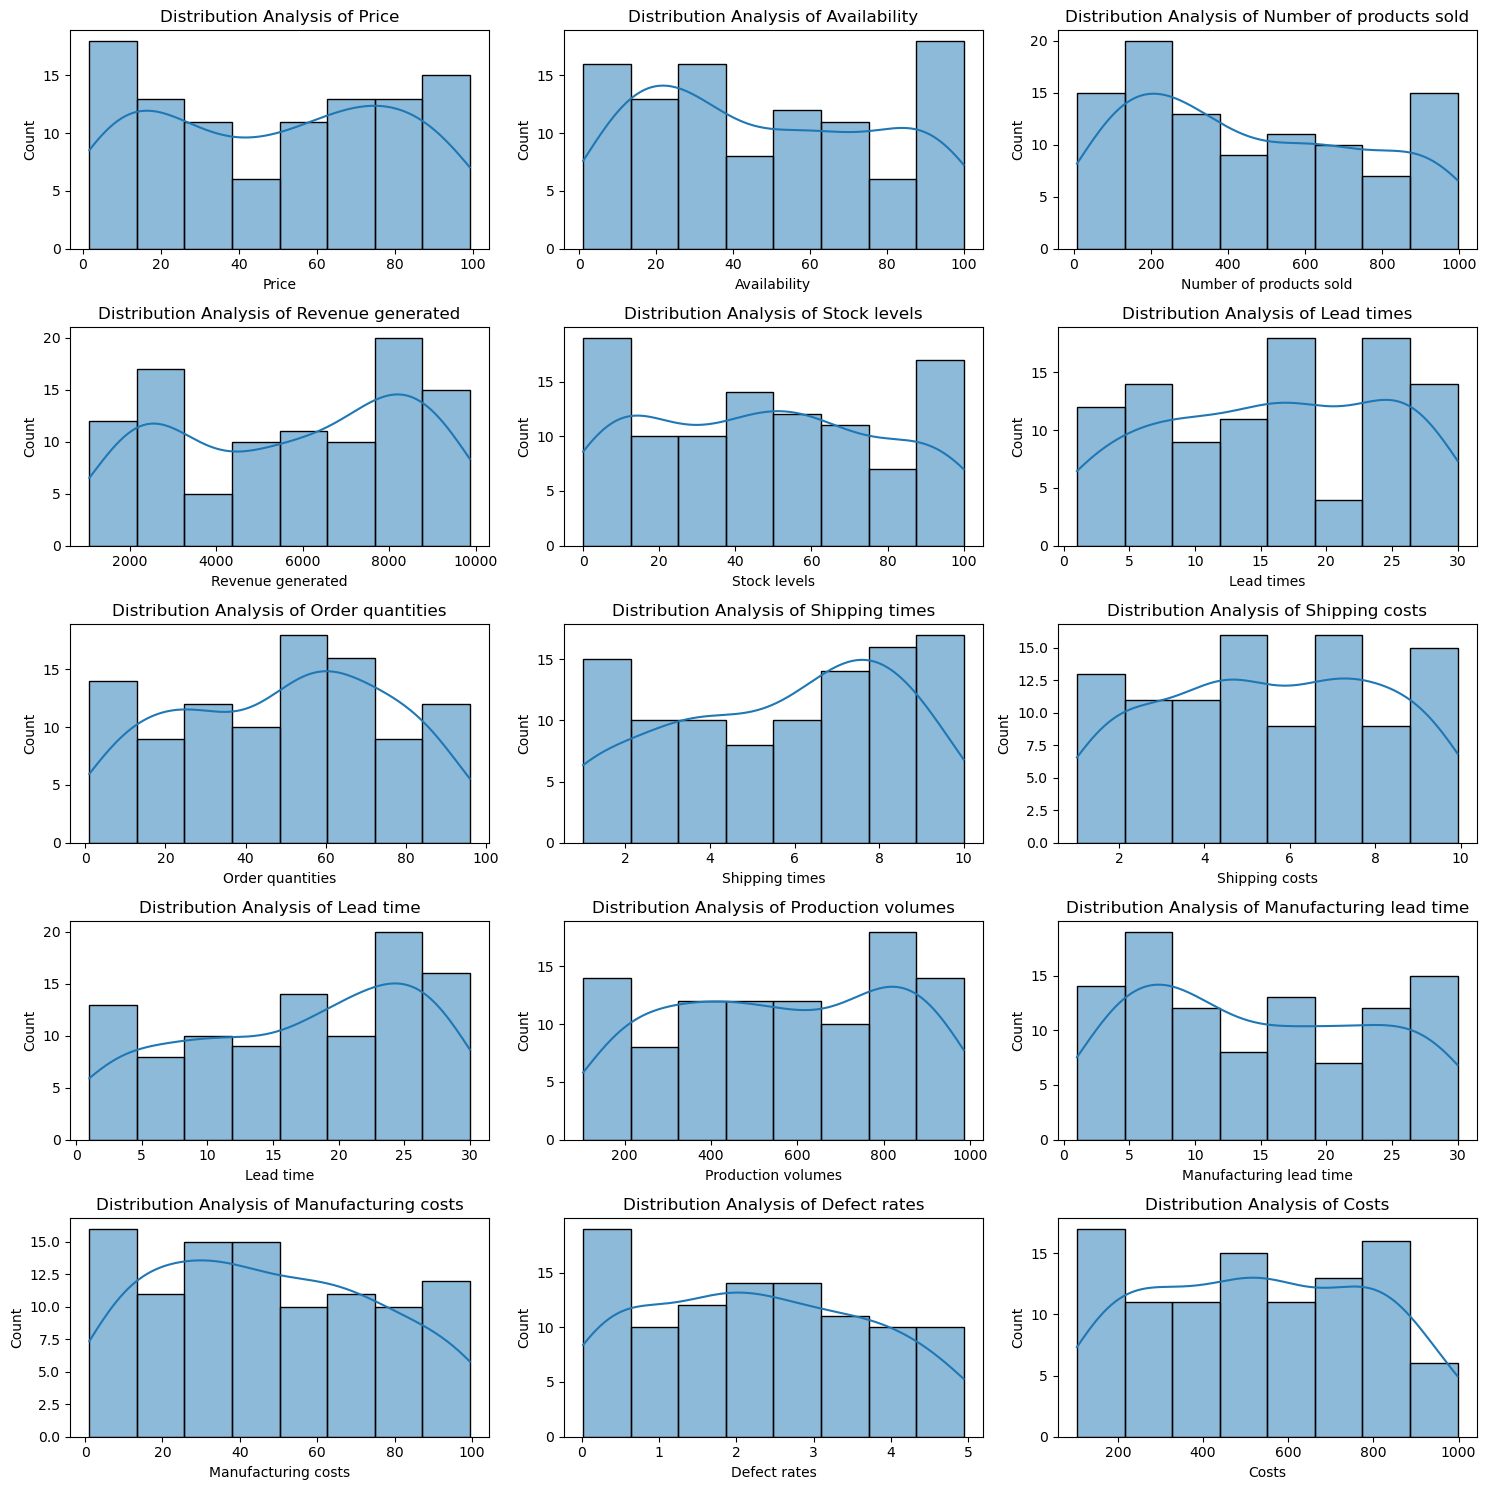

In [563]:
# Distribution Plot -> only for numerical columns

fig, axes = plt.subplots(5, 3, figsize = (15, 15))
axes = axes.flatten()

num_col = df.select_dtypes(include =  "number").columns
for i, j in enumerate(num_col):
    sns.histplot(df[j], kde = True, ax = axes[i])
    axes[i].set_title(f"Distribution Analysis of {j}")

plt.tight_layout()
plt.show()


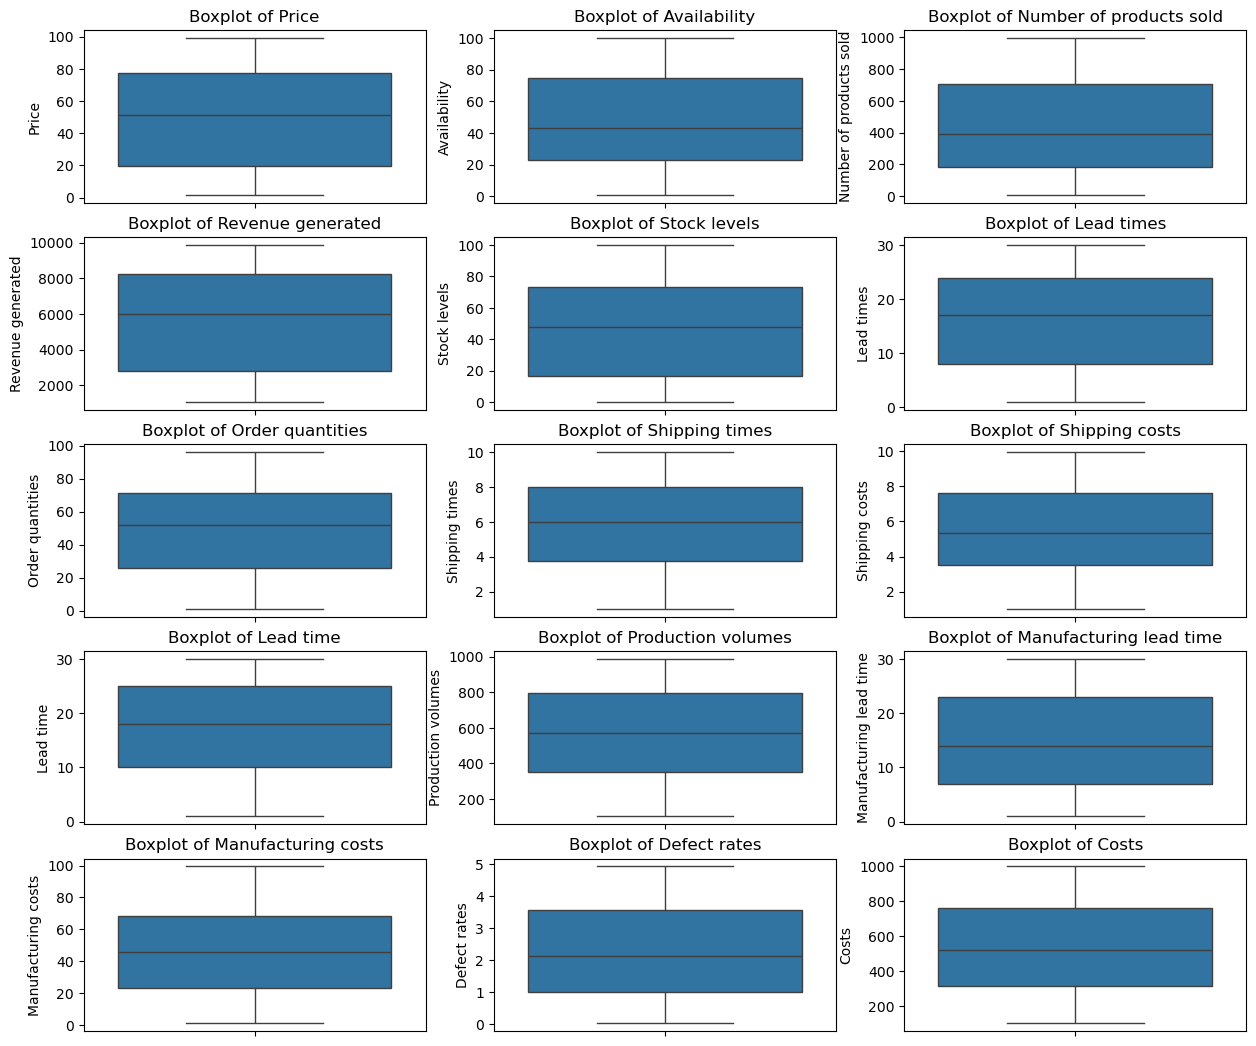

In [564]:
## Boxplot 
fig, axes = plt.subplots(5, 3 , figsize = (15, 13))
axes = axes.flatten()

for i, j in enumerate(num_col):
    sns.boxplot(df[j], ax = axes[i])
    axes[i].set_title(f"Boxplot of {j}")

plt.show()

In [565]:
## correlation matrix

### Categorical EDA
- value count
- count plot

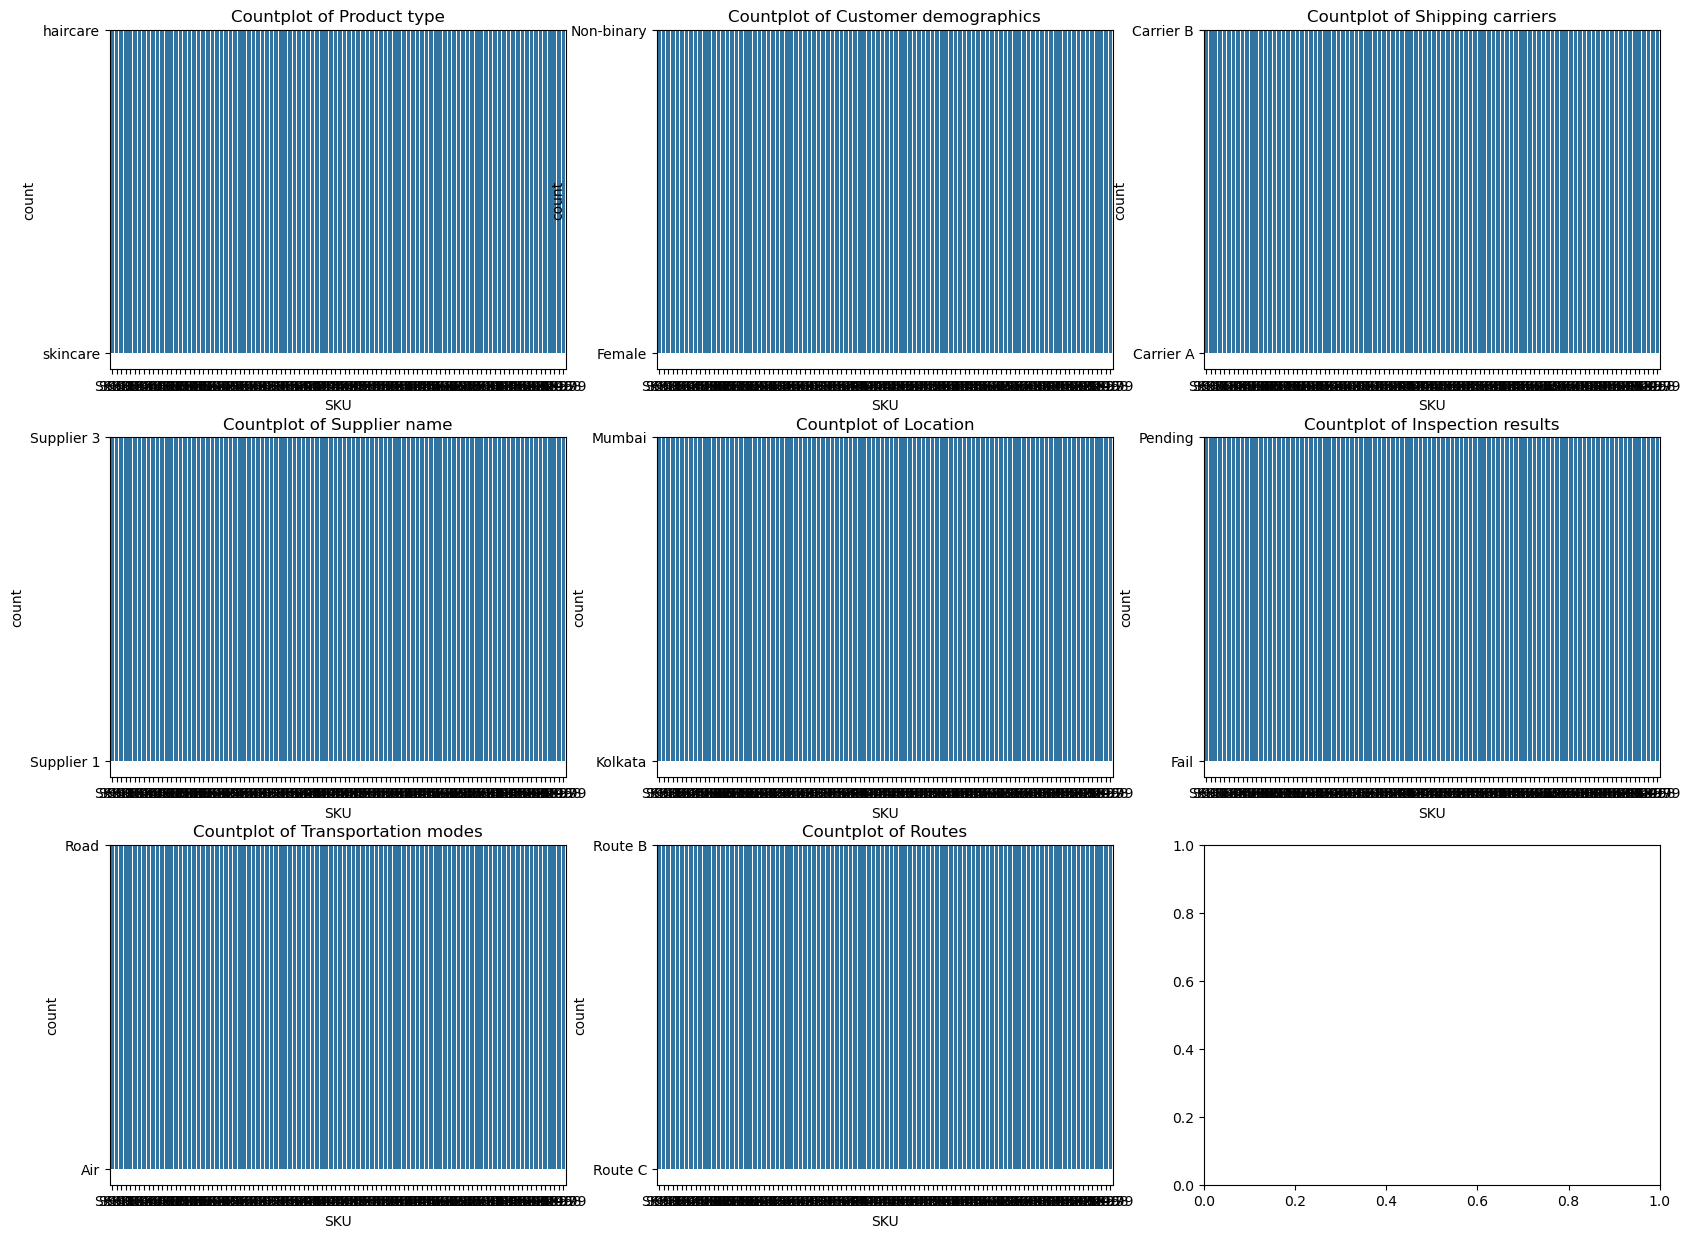

In [566]:
## Count plot - for categorical variables
fig, axes = plt.subplots(3, 3 , figsize = (20, 15))
axes = axes.flatten()

cat_col = df.select_dtypes(include = "object").columns

for i, j in enumerate(cat_col):
    sns.countplot(df[j], ax = axes[i])
    axes[i].set_title(f"Countplot of {j}")

plt.show()

In [567]:
print(df.index.name)
print(df.columns)
print(cat_col)

SKU
Index(['Product type', 'Price', 'Availability', 'Number of products sold',
       'Revenue generated', 'Customer demographics', 'Stock levels',
       'Lead times', 'Order quantities', 'Shipping times', 'Shipping carriers',
       'Shipping costs', 'Supplier name', 'Location', 'Lead time',
       'Production volumes', 'Manufacturing lead time', 'Manufacturing costs',
       'Inspection results', 'Defect rates', 'Transportation modes', 'Routes',
       'Costs'],
      dtype='object')
Index(['Product type', 'Customer demographics', 'Shipping carriers',
       'Supplier name', 'Location', 'Inspection results',
       'Transportation modes', 'Routes'],
      dtype='object')


## Relationship Analysis
- scatter plot
- pairplot

outlier detection 
kurtosis 
skewness


## Logistic Regression: Inspection Failure

## Creating the Target Variable

The original `Inspection results` column contains three classes:

- Pass
- Fail
- Pending

Since logistic regression is designed for binary classification, this project focuses on predicting whether a product **passes** or **fails** inspection.

Records labelled **Pending** are removed because they do not represent a final inspection outcome.

In [568]:
# remove pending inspections and create binary target
df = df[df['Inspection results'] != 'pending'].copy()

df['Inspection fail'] = (
    df['Inspection results'] == 'Fail'
).astype(int)

In [569]:
features = [
    "Price",
    "Availability",
    "Stock levels",
    "Lead time",
    "Manufacturing costs",
    "Defect rates",
    "Shipping costs",
    "Product type",
    "Transportation modes",
    "Location"
]

In [570]:
# X - product characteristics, y - inspection failure

X = df[features].copy()

y = df['Inspection fail']

In [571]:
# defining numerical and categorical features

categorical_features = [
    "Product type",
    "Transportation modes",
    "Location"
]

In [572]:
# One cot Encoding
X = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first = True,
    dtype=int
)

In [573]:
# there should be no object columns
X.dtypes

Price                        float64
Availability                   int64
Stock levels                   int64
Lead time                      int64
Manufacturing costs          float64
Defect rates                 float64
Shipping costs               float64
Product type_haircare          int64
Product type_skincare          int64
Transportation modes_Rail      int64
Transportation modes_Road      int64
Transportation modes_Sea       int64
Location_Chennai               int64
Location_Delhi                 int64
Location_Kolkata               int64
Location_Mumbai                int64
dtype: object

In [574]:
X.columns

Index(['Price', 'Availability', 'Stock levels', 'Lead time',
       'Manufacturing costs', 'Defect rates', 'Shipping costs',
       'Product type_haircare', 'Product type_skincare',
       'Transportation modes_Rail', 'Transportation modes_Road',
       'Transportation modes_Sea', 'Location_Chennai', 'Location_Delhi',
       'Location_Kolkata', 'Location_Mumbai'],
      dtype='object')

To evaluate how well the model generalizes to unseen data, the dataset is divided into:

- Training set (80%)
- Testing set (20%)

In [575]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [576]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size = 0.2,
    random_state = 42,
    stratify=y
)

For logistic Regression, typically, we do not need to scale but since our variables span very different ranges, it would be helpful to scale

In [ ]:
scaler = StandardScaler()

X_train[features] = scaler.fit_transform(
    X_train[features]
)

X_test[features] = scaler.fit_transform(
    X_test[features]
)

KeyError: "['Product type', 'Transportation modes', 'Location'] not in index"

In [578]:
import statsmodels.api as sm

# adding the intercept
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

# convert everything to numeric
X_train_sm = X_train_sm.astype(float)
X_test_sm = X_test_sm.astype(float)

In [582]:
logit_model = sm.Logit(y_train, X_train_sm)

result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.562706
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:        Inspection fail   No. Observations:                   80
Model:                          Logit   Df Residuals:                       63
Method:                           MLE   Df Model:                           16
Date:                Wed, 22 Jul 2026   Pseudo R-squ.:                  0.1407
Time:                        20:00:04   Log-Likelihood:                -45.016
converged:                       True   LL-Null:                       -52.387
Covariance Type:            nonrobust   LLR p-value:                    0.5436
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -0.8564      1.614     -0.531      0.596      -4.

In [585]:
result = sm.Logit(y_train, X_train_sm).fit()
y_prob = result.predict(X_test_sm)
y_prob

Optimization terminated successfully.
         Current function value: 0.562706
         Iterations 6


SKU
SKU81    0.674884
SKU84    0.762851
SKU80    0.392294
SKU11    0.325342
SKU26    0.211633
SKU7     0.130841
SKU21    0.349201
SKU98    0.387795
SKU41    0.108780
SKU15    0.212003
SKU57    0.754422
SKU32    0.191420
SKU4     0.719456
SKU17    0.522867
SKU97    0.254006
SKU69    0.192867
SKU48    0.194246
SKU34    0.534929
SKU30    0.238530
SKU43    0.183567
dtype: float64

In [589]:
y_pred = (y_prob >= 0.5).astype(int)
prediction = np.where(y_pred == 1, "Fail", "Pass")

In [590]:
results = pd.DataFrame({
    "Actual": np.where(y_test == 1, "Fail", "Pass"),
    "Predicted": prediction,
    "Probability of Failure": y_prob.round(3)
})

results.head(10)

,Actual,Predicted,Probability of Failure
SKU,,,
SKU81,Pass,Fail,0.675
SKU84,Pass,Fail,0.763
SKU80,Fail,Pass,0.392
SKU11,Pass,Pass,0.325
SKU26,Pass,Pass,0.212
SKU7,Fail,Pass,0.131
SKU21,Pass,Pass,0.349
SKU98,Pass,Pass,0.388
SKU41,Fail,Pass,0.109


In [591]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy: ", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy:  0.55
[[9 4]
 [5 2]]
              precision    recall  f1-score   support

           0       0.64      0.69      0.67        13
           1       0.33      0.29      0.31         7

    accuracy                           0.55        20
   macro avg       0.49      0.49      0.49        20
weighted avg       0.53      0.55      0.54        20



## Problem Arised
